# TS 2025 - Assignment 2

Before you begin, set the assignment seed to the student id of one of your team members in the cell below.
To choose the data for this set the assignment seed to the student id of one of the team members. The
cell is prefilled with an **example** student id, so make sure to change it and **run the cell** before proceeding
further.

In [1]:
# NB!: change this to the student id of one of your team members

assignment_seed = "2675"

## Presentation

Do not create powerpoint slides or similar presentations for this assignment. The only submission should be
this Jupyter notebook with the completed code and results.

For the presentation of your results please **only include**:

    - Plots
    - Numeric results
    - Tables of model parameters and summaries

**Do not include**:

    - Text in comments or markdown cells
    - Custom functions in the code
    - if-then-else statements or similar control flow structures
    - Loops (for, while, etc.)
    - Any other code that is not directly related to the assignment tasks
  
**Explanations**

For the presentation you should be able to explain all the steps and be able to answer questions about

- Why you use a specific model/test/plot
- What is shown in the plots and numeric results
- How to interpret the results
  
## Tasks

1. Run the following cell to load your data. It will be stored in the pandas Series `dt`. All time series
are stock prices from the SOFIX index. The data that you should use for the model selection is stored in the
series `train`. The data for testing the forecasts is stored in the series `test`.

2. Adjust the labels and titles of the plots to reflect the stock you are analyzing
3. Your task is to select an ARIMA model for the stock price.
   - Choose the order of differencing based on the ACF/PACF plots and unit root tests (ADF, KPSS)
   - Choose the AR and MA orders based on the ACF/PACF plots and information criteria (AIC, BIC)
4. After selecting the ARIMA model, analyze the residuals
   - Plot the residuals and their ACF/PACF
   - Perform the Ljung-Box test on the residuals
   - Plot the histogram and QQ-plot of the residuals
5. Analyze the volatility of the residuals using an appropriate plot
6. Fit several ARCH/GARCH models to the residuals
   - Plot the conditional volatility
   - Analyze the standardized residuals of the GARCH model (plots, Ljung-Box test, histogram, QQ-plot)
   - Test whether negative and positive shocks have different effects on volatility
  
7. Forecast the stock prices for the test period using the ARIMA model in two ways:
   - By manually differencing the data before fitting the ARIMA model
   - By using the integrated ARIMA model directly
   - Compare the forecasts from both methods and explain the differences, explain the meaning of an
     intercept in the ARIMA model with differenced data
   - Plot the forecasts along with the actual values
   - Compute the RMSE of the forecasts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 17.0 MB/s eta 0:00:00


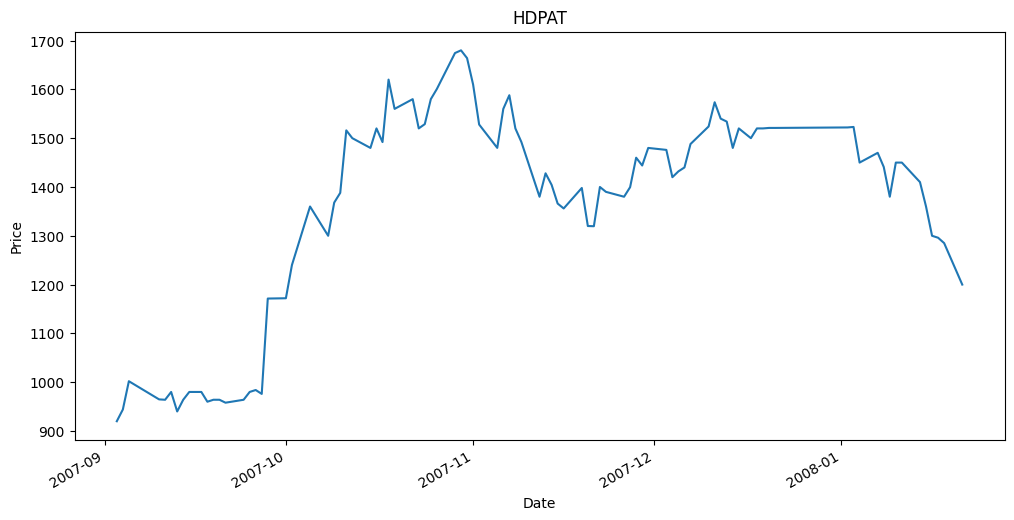

In [2]:

%pip install arch

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from scipy import stats
import numpy as np

np.random.seed(int(re.sub(r"\D", "", assignment_seed)))

stocks = pd.read_excel("https://github.com/febse/data/raw/refs/heads/main/ts/SOFIX-Stocks.xlsx", usecols="A:Q").set_index("Date")

dt = stocks[np.random.choice(stocks.columns)]

train_size = int(len(dt) * 0.85)
train, test = dt[:train_size], dt[train_size:]


train.plot(title="Stock Price", figsize=(12, 6))

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("HDPAT")
plt.show()

In [3]:
print(f"The stock being analyzed is: {dt.name}")

The stock being analyzed is: HDPAT


In [4]:
from statsmodels.tsa.stattools import adfuller

def show_adf_result(result):

    adf_stat = result[0]
    pvalue = result[1]
    critical_values = result[2]
    resstore = result[3]

    print("Augmented Dickey-Fuller Test Results")
    print("=" * 60)
    print(f"ADF Statistic: {adf_stat:.6f}")
    print(f"p-value: {pvalue:.6f}")
    print(f"Critical Values:")
    for k, v in critical_values.items():
        print(f"  {k}: {v:.2f}")
    print("=" * 60)
    print(resstore.resols.summary())


print("\n--- ADF Test on Original Training Data ---")

result_original_adf = adfuller(train.dropna(), regression='c', autolag='AIC', regresults=True, store=True)
show_adf_result(result_original_adf)


--- ADF Test on Original Training Data ---
Augmented Dickey-Fuller Test Results
ADF Statistic: -1.939065
p-value: 0.313912
Critical Values:
  1%: -3.50
  5%: -2.89
  10%: -2.58
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.760
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0556
Time:                        10:58:20   Log-Likelihood:                -492.21
No. Observations:                  93   AIC:                             988.4
Df Residuals:                      91   BIC:                             993.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err

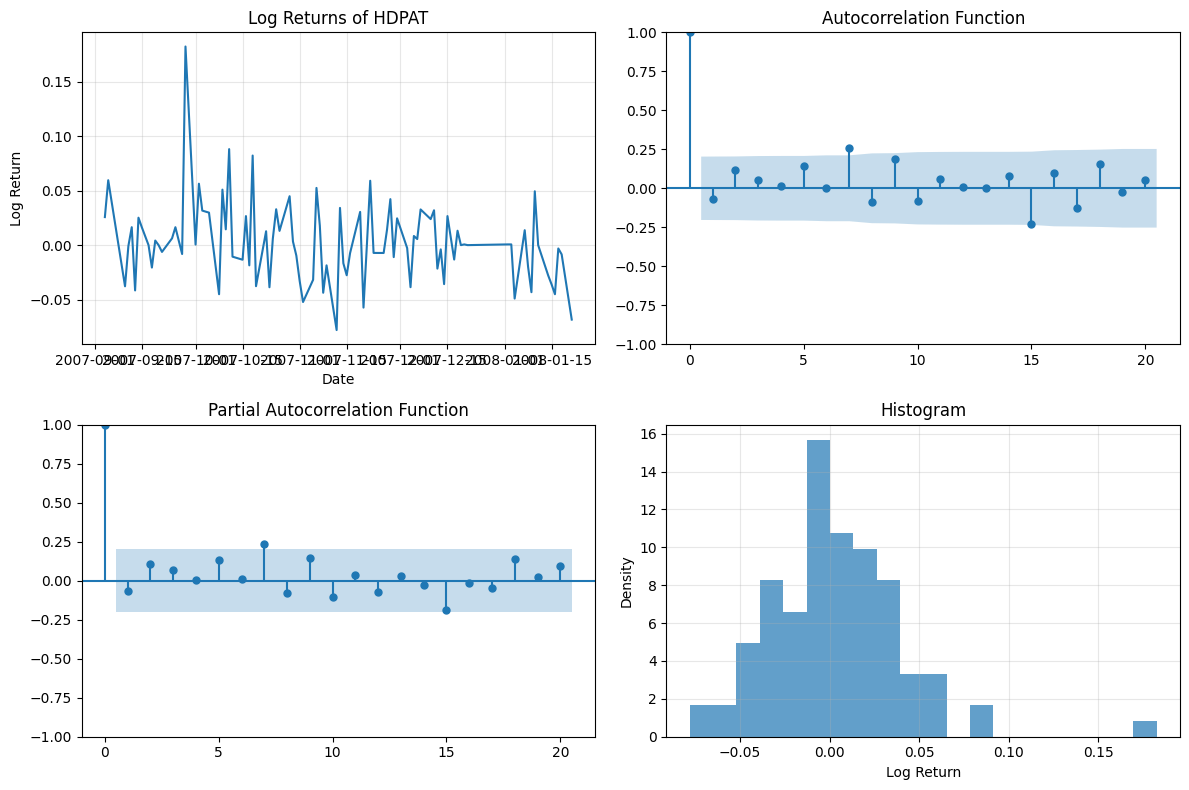

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


log_returns = np.log(train).diff().dropna()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(log_returns)
ax[0, 0].set_title(f"Log Returns of {dt.name}")
ax[0, 0].set_xlabel("Date")
ax[0, 0].set_ylabel("Log Return")
ax[0, 0].grid(alpha=0.3)

plot_acf(log_returns, lags=20, ax=ax[0, 1])
ax[0, 1].set_title(f"Autocorrelation Function")

plot_pacf(log_returns, lags=20, method="ywm", ax=ax[1, 0])
ax[1, 0].set_title(f"Partial Autocorrelation Function")

ax[1, 1].hist(log_returns, bins=20, density=True, alpha=0.7)
ax[1, 1].set_title(f"Histogram")
ax[1, 1].set_xlabel("Log Return")
ax[1, 1].set_ylabel("Density")
ax[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
print("\n--- ADF Test on First-Differenced Training Data ---")

result_diff = adfuller(log_returns, regression='c', autolag='AIC', regresults=True, store=True)
show_adf_result(result_diff)



--- ADF Test on First-Differenced Training Data ---
Augmented Dickey-Fuller Test Results
ADF Statistic: -9.973495
p-value: 0.000000
Critical Values:
  1%: -3.50
  5%: -2.89
  10%: -2.58
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     99.47
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           3.24e-16
Time:                        10:58:40   Log-Likelihood:                 172.55
No. Observations:                  92   AIC:                            -341.1
Df Residuals:                      90   BIC:                            -336.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef  

In [7]:
from statsmodels.tsa.stattools import kpss

def show_kpss_result(result, series_name):
    kpss_stat = result[0]
    pvalue = result[1]
    lags = result[2]
    critical_values = result[3]

    print(f"KPSS Test Results for {series_name}")
    print("=" * 60)
    print(f"KPSS Statistic: {kpss_stat:.6f}")
    print(f"p-value: {pvalue:.6f}")
    print(f"Number of Lags Used: {lags}")
    print(f"Critical Values:")
    for k, v in critical_values.items():
        print(f"  {k}: {v:.2f}")
    print("=" * 60)


print("\n--- KPSS Test on Original Training Data ---")
result_original_kpss = kpss(train.dropna(), regression='c', nlags='auto')
show_kpss_result(result_original_kpss, "Original Training Data")


print("\n--- KPSS Test on First-Differenced Training Data ---")


result_diff_kpss = kpss(log_returns, regression='c', nlags='auto')
show_kpss_result(result_diff_kpss, "First-Differenced Training Data")


--- KPSS Test on Original Training Data ---
KPSS Test Results for Original Training Data
KPSS Statistic: 0.780842
p-value: 0.010000
Number of Lags Used: 5
Critical Values:
  10%: 0.35
  5%: 0.46
  2.5%: 0.57
  1%: 0.74

--- KPSS Test on First-Differenced Training Data ---
KPSS Test Results for First-Differenced Training Data
KPSS Statistic: 0.629818
p-value: 0.019926
Number of Lags Used: 2
Critical Values:
  10%: 0.35
  5%: 0.46
  2.5%: 0.57
  1%: 0.74


/tmp/ipython-input-2284308701.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_original_kpss = kpss(train.dropna(), regression='c', nlags='auto')


In [8]:
arima1_1_0 = ARIMA(np.log(train), order=(1, 1, 0)).fit()
arima0_1_1 = ARIMA(np.log(train), order=(0, 1, 1)).fit()
arima2_1_0 = ARIMA(np.log(train), order=(2, 1, 0)).fit()
arima1_1_1 = ARIMA(np.log(train), order=(1, 1, 1)).fit()

print(arima1_1_1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 174.578
Date:                Wed, 14 Jan 2026   AIC                           -343.156
Time:                        10:58:47   BIC                           -335.559
Sample:                             0   HQIC                          -340.089
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4312      1.056     -0.408      0.683      -2.501       1.638
ma.L1          0.3547      1.117      0.317      0.751      -1.835       2.545
sigma2         0.0014      0.000     12.492      0.0

In [9]:
print("\n--- ARIMA(0,1,1) Model Summary ---")
print(arima0_1_1.summary())


--- ARIMA(0,1,1) Model Summary ---
                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 174.384
Date:                Wed, 14 Jan 2026   AIC                           -344.767
Time:                        10:59:05   BIC                           -339.702
Sample:                             0   HQIC                          -342.722
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0483      0.153     -0.316      0.752      -0.348       0.251
sigma2         0.0014      0.000     12.650      0.000       0.001       0.002
Ljung-Box (L1) (

In [10]:
print("\n--- ARIMA(1,1,1) Model Summary ---")
print(arima1_1_1.summary())


--- ARIMA(1,1,1) Model Summary ---
                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 174.578
Date:                Wed, 14 Jan 2026   AIC                           -343.156
Time:                        10:59:19   BIC                           -335.559
Sample:                             0   HQIC                          -340.089
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4312      1.056     -0.408      0.683      -2.501       1.638
ma.L1          0.3547      1.117      0.317      0.751      -1.835       2.545
sigma2         0

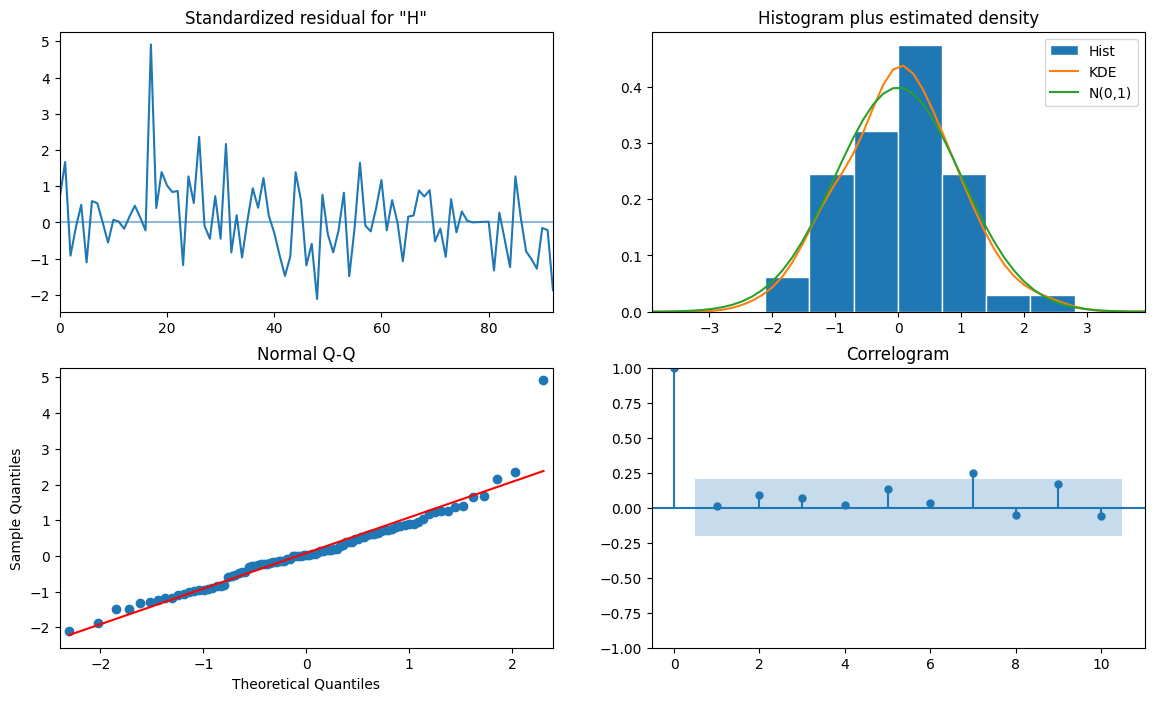

In [11]:
arima1_1_1.plot_diagnostics(figsize=(14, 8))
plt.show()

<Figure size 1000x400 with 0 Axes>

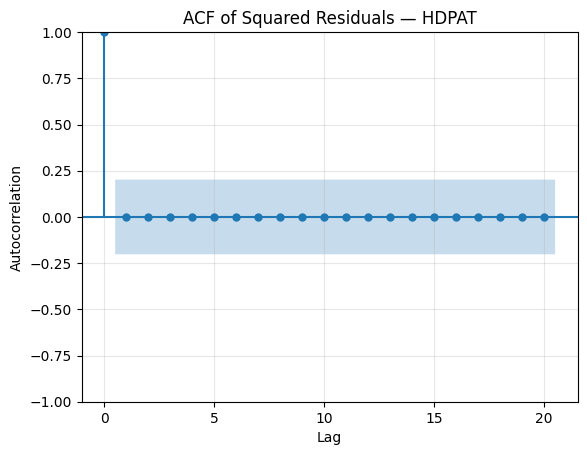

In [12]:
residuals = arima1_1_1.resid
residuals_sq = residuals ** 2

plt.figure(figsize=(10,4))

plot_acf(residuals_sq, lags=min(20, len(residuals_sq)-1))
plt.title("ACF of Squared Residuals — HDPAT")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()


In [13]:
scaled_garch_model = arch_model(residuals, mean='Zero', vol='GARCH', p=1, q=1)
scaled_garch_results = scaled_garch_model.fit(disp='off')

print(scaled_garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.011
Vol Model:                      GARCH   Log-Likelihood:                149.143
Distribution:                  Normal   AIC:                          -292.287
Method:            Maximum Likelihood   BIC:                          -284.657
                                        No. Observations:                   94
Date:                Wed, Jan 14 2026   Df Residuals:                       94
Time:                        10:59:44   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      1.2798e-03  4.990e-04      2.565  1.033e-02 

<Figure size 1000x400 with 0 Axes>

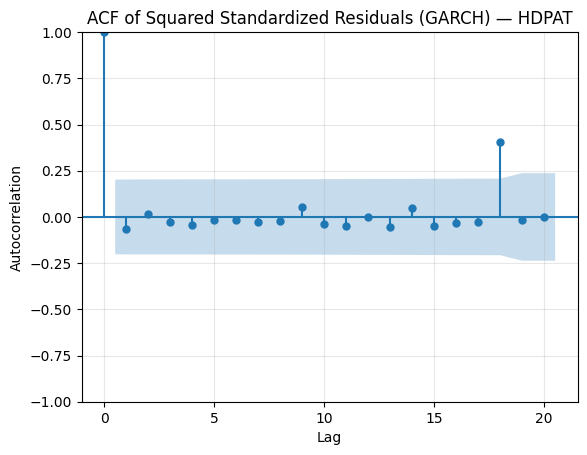

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

std_resid = scaled_garch_results.std_resid
std_resid_sq = std_resid ** 2

plt.figure(figsize=(10, 4))
plot_acf(std_resid_sq, lags=20)
plt.title(f"ACF of Squared Standardized Residuals (GARCH) — {dt.name}")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()

In [15]:
gjr_model = arch_model(
    residuals,
    mean="Zero",
    vol="GARCH",
    p=1,
    o=1,
    q=1
)
gjr_res = gjr_model.fit(disp="off")
print(gjr_res.summary())


                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.011
Vol Model:                  GJR-GARCH   Log-Likelihood:                133.885
Distribution:                  Normal   AIC:                          -259.771
Method:            Maximum Likelihood   BIC:                          -249.598
                                        No. Observations:                   94
Date:                Wed, Jan 14 2026   Df Residuals:                       94
Time:                        11:00:02   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.8187e-03  1.237e-03      2.279  2.268e-02 [3.

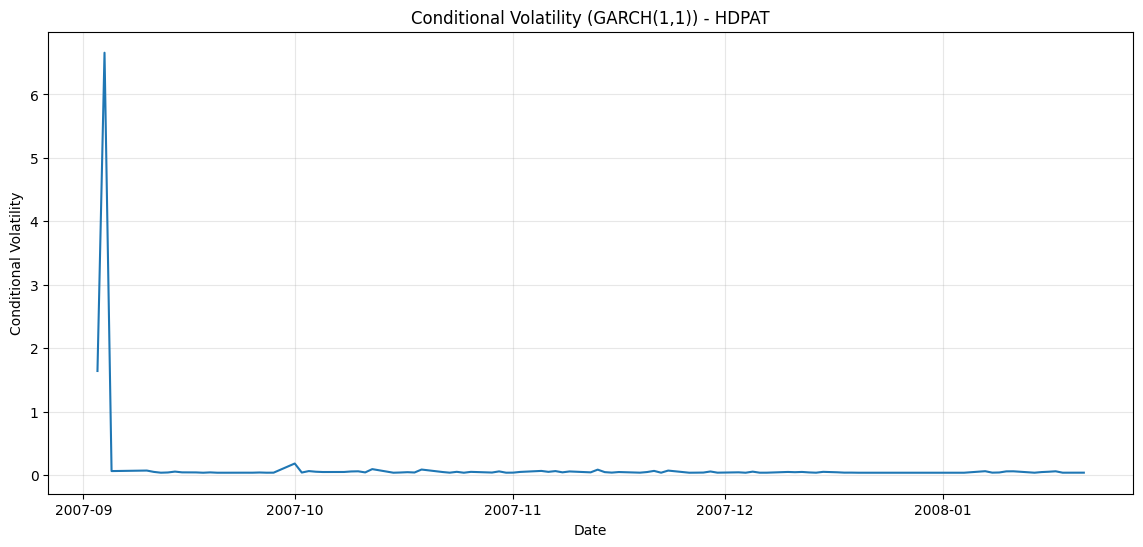

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(scaled_garch_results.conditional_volatility)
plt.title(f'Conditional Volatility (GARCH(1,1)) - {dt.name}')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.grid(alpha=0.3)
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

h = 8
y_forecast = arima1_1_1.forecast(steps=h)
test = test.dropna()

y_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
94,7.094988
95,7.092871
96,7.093784
97,7.093390
98,7.093560
99,7.093487
100,7.093518
101,7.093505


In [18]:
np.log(test)

,HDPAT
Date,
2008-01-22,7.027315
2008-01-23,7.057039
2008-01-24,7.094235
2008-01-25,7.126087
2008-01-28,7.090078
2008-01-29,7.088409
2008-01-30,7.079184
2008-01-31,7.060476


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

h = 8
y_forecast = arima0_1_1.forecast(steps=h)
test = test.dropna()

y_forecast

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

h = 8
y_forecast = arima0_1_1.forecast(steps=h)
test2 = test.dropna()

y_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
94,7.093401
95,7.093401
96,7.093401
97,7.093401
98,7.093401
99,7.093401
100,7.093401
101,7.093401


In [20]:
np.log(test2)

,HDPAT
Date,
2008-01-22,7.027315
2008-01-23,7.057039
2008-01-24,7.094235
2008-01-25,7.126087
2008-01-28,7.090078
2008-01-29,7.088409
2008-01-30,7.079184
2008-01-31,7.060476


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

h = 8
y_forecast = arima2_1_0.forecast(steps=h)
test3 = test.dropna()

y_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
94,7.092520
95,7.084067
96,7.084794
97,7.083729
98,7.083871
99,7.083734
100,7.083759
101,7.083741


In [22]:
np.log(test3)

,HDPAT
Date,
2008-01-22,7.027315
2008-01-23,7.057039
2008-01-24,7.094235
2008-01-25,7.126087
2008-01-28,7.090078
2008-01-29,7.088409
2008-01-30,7.079184
2008-01-31,7.060476


In [23]:
# Compute RMSE

rmse = np.sqrt(mean_squared_error(np.log(test), y_forecast))
print(f"RMSE of the forecast: {rmse:.6f}")

RMSE of the forecast: 0.030595


In [24]:
y_forecast.index = test.index

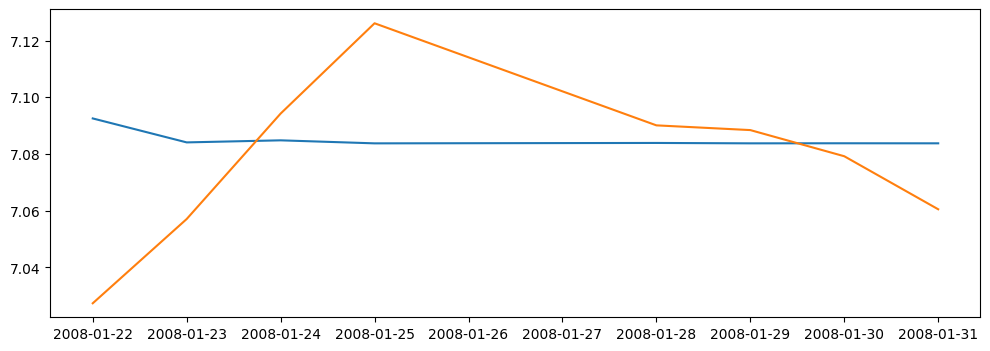

In [25]:
plt.figure(figsize=(12,4))
plt.plot(y_forecast, label="Forecast (log)")
plt.plot(np.log(test), label="Actual (log)")
